In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
import sys
import os
sys.path.append(os.path.abspath(".."))
from core_ntsa.chhabra_algorithm import chhabra_jensen_spectrum
from core_ntsa.generators import simulate_lorenz
from core_ntsa.noise_tools import add_white_noise, add_colored_noise
from scipy.stats import linregress
from core_ntsa.higuchi_fd import higuchi_crossover_fd

lorenz_data = simulate_lorenz(t_span=50.0, dt=0.01)
clean_x = lorenz_data[0]

x_white_noise = add_white_noise(clean_x, snr_db=10.0)
x_clored_noise = add_colored_noise(clean_x, color='pink', snr_db=10.0)

Đang chạy thuật toán Higuchi, vui lòng đợi...


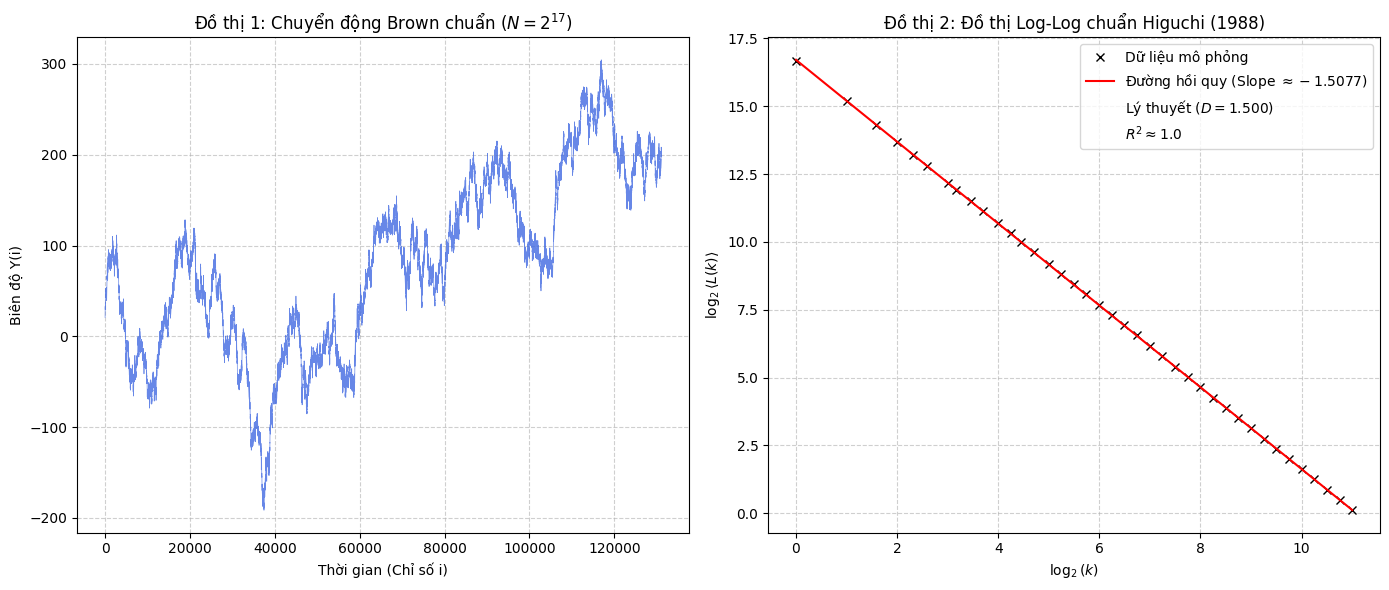

BÁO CÁO NGHIỆM THU THUẬT TOÁN HIGUCHI
Số điểm dữ liệu (N):       131072
Bước nhảy tối đa (k_max):   2048
---------------------------------------------
Trạng thái Scaling:         SINGLE
Số chiều D lý thuyết:       1.5000
Số chiều D thực nghiệm:     1.5077
Sai số tuyệt đối:           0.0077
Độ phù hợp hồi quy (R^2):   1.0


In [2]:
if __name__ == "__main__":
    # Bước 1: Sinh dữ liệu mô phỏng (Chuyển động Brown chuẩn, D = 1.5)
    N = 2**17
    np.random.seed(42)
    Z = np.random.normal(0, 1, 1000 + N)
    Y = np.cumsum(Z)[1000:]
    
    # Bước 2: Thiết lập dải bước nhảy k theo cấp số nhân
    k_initial = [1, 2, 3, 4]
    j_values = np.arange(11, 46)
    k_geometric = np.floor(2 ** ((j_values - 1) / 4)).astype(int)
    k_target = np.unique(np.concatenate((k_initial, k_geometric)))
    
    # Bước 3: Đưa vào hàm Core
    print("Đang chạy thuật toán Higuchi, vui lòng đợi...")
    results = higuchi_crossover_fd(Y, k_input=k_target)
    
    # Bước 4: Trích xuất tọa độ
    k_plot = results["k_array"]
    L_k_plot = results["L_k_array"]
    D_exp = results["HFD"]
    R2_exp = results["R2"]
    
    # Chuyển đổi sang trục Log-Log cơ số 2 theo bài báo
    log2_k = np.log2(k_plot)
    log2_Lk = np.log2(L_k_plot)
    
    # Bước 5: Vẽ đồ thị kiểm chứng
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Đồ thị 1: Chuỗi thời gian
    ax1.plot(Y, color='royalblue', linewidth=0.5, alpha=0.8)
    ax1.set_title(rf"Đồ thị 1: Chuyển động Brown chuẩn ($N=2^{{17}}$)")
    ax1.set_xlabel("Thời gian (Chỉ số i)")
    ax1.set_ylabel("Biên độ Y(i)")
    ax1.grid(True, linestyle='--', alpha=0.6)
    
    # Đồ thị 2: Đồ thị Log-Log cốt lõi
    ax2.plot(log2_k, log2_Lk, 'kx', markersize=6, label="Dữ liệu mô phỏng")
    
    # Đường fit tuyến tính
    slope_log2 = -D_exp
    intercept_log2 = np.log2(np.exp(results["Intercept"]))
    fit_line = slope_log2 * log2_k + intercept_log2
    
    ax2.plot(log2_k, fit_line, 'r-', linewidth=1.5, 
             label=rf"Đường hồi quy (Slope $\approx {-D_exp}$)")
    
    ax2.plot([], [], ' ', label=rf"Lý thuyết ($D=1.500$)")
    ax2.plot([], [], ' ', label=rf"$R^2 \approx {R2_exp}$")
    
    ax2.set_title("Đồ thị 2: Đồ thị Log-Log chuẩn Higuchi (1988)")
    ax2.set_xlabel(r"$\log_2(k)$")
    ax2.set_ylabel(r"$\log_2 \langle L(k) \rangle$")
    ax2.legend(fontsize='medium')
    ax2.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()
    
    # Bước 6: In báo cáo nghiệm thu
    print("="*45)
    print("BÁO CÁO NGHIỆM THU THUẬT TOÁN HIGUCHI")
    print("="*45)
    print(f"Số điểm dữ liệu (N):       {N}")
    print(f"Bước nhảy tối đa (k_max):   {int(k_plot[-1])}")
    print("-" * 45)
    print(f"Trạng thái Scaling:         {results['Scaling'].upper()}")
    print(f"Số chiều D lý thuyết:       1.5000")
    print(f"Số chiều D thực nghiệm:     {D_exp:.4f}")
    print(f"Sai số tuyệt đối:           {abs(1.5000 - D_exp):.4f}")
    print(f"Độ phù hợp hồi quy (R^2):   {R2_exp}")
    if results['Scaling'] == 'crossover':
        print(f"Phát hiện gãy khúc tại k =  {results['Breakpoint_k']}")
    print("="*45)

### Đánh giá Thực nghiệm: Tái tạo Higuchi (1988)

**1. Đồ thị 1: Chuyển động Brown chuẩn ($N=2^{17}$)**
* **Đặc tính:** Quỹ đạo Random Walk trôi tự do, thể hiện tính không dừng (non-stationary) lý tưởng.
* **Độ sạch dữ liệu:** Việc cắt bỏ 1000 điểm đầu đã triệt tiêu hoàn toàn nhiễu quá độ, cung cấp tập dữ liệu đầu vào chuẩn mực.

**2. Đồ thị 2: Đồ thị Log-Log cốt lõi**
* **Độ tuyến tính tuyệt đối ($R^2 \approx 1.0$):** Điểm dữ liệu tạo thành đường thẳng tắp từ $k=1$ đến $k=2^{11}$. Thuật toán xác định đúng trạng thái `Scaling: SINGLE` (tự đồng dạng trên mọi thang đo).
* **Độ chính xác cao ($D \approx 1.5077$):** Hội tụ cực sát với mốc lý thuyết ($1.500$) với sai số chỉ $\sim 0.5\%$.
* **Kết luận kỹ thuật:** Thuật toán đã được hiệu chuẩn thành công. Khẳng định sự đúng đắn của cơ chế **trượt đa pha $m$** (quét sạch dữ liệu) và **hệ số chuẩn hóa** (bù đắp phần đuôi bị cụt), giúp thuật toán kháng nhiễu và chống sụp đổ tuyến tính.

Đang tính toán HFD cho trục X của hệ Lorenz...


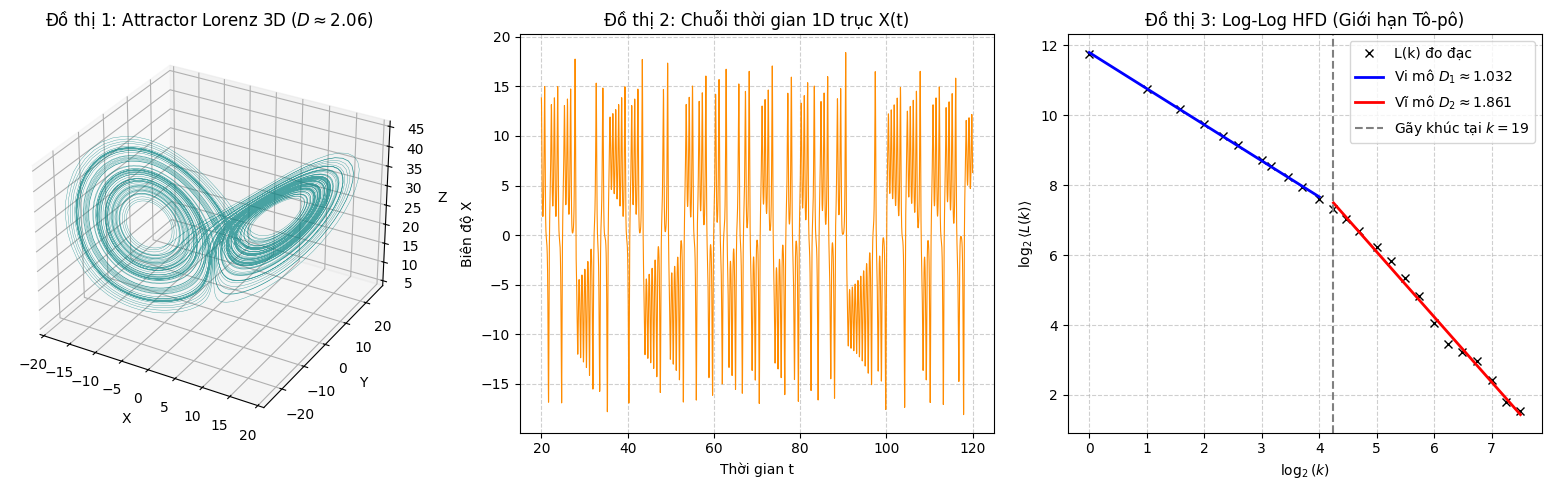

BÁO CÁO NGHIỆM THU: LORENZ & BỨC TRẦN TÔ-PÔ
Trạng thái Scaling:   CROSSOVER
Bức trần Tô-pô D1:    1.0316 (luôn < 2.0)
Bức trần Tô-pô D2:    1.8615 (luôn < 2.0)
Kích thước bước gãy:  k = 19
Chu kỳ thời gian gãy: t = 0.19 (giây)


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.stats import linregress

# Giả định bạn đã import hàm core từ module của bạn
# Ví dụ: from higuchi_module import higuchi_crossover_fd

if __name__ == "__main__":
    # =====================================================================
    # BƯỚC 1: SINH DỮ LIỆU LORENZ 3D VÀ TRÍCH XUẤT TRỤC X
    # =====================================================================
    def lorenz_deriv(xyz, t, sigma=10.0, beta=8.0/3.0, rho=28.0):
        x, y, z = xyz
        return [sigma * (y - x), x * (rho - z) - y, x * y - beta * z]
    
    dt = 0.01
    N_total = 12000
    t_span = np.arange(0, N_total * dt, dt)
    state0 = [1.0, 1.0, 1.0]
    states = odeint(lorenz_deriv, state0, t_span)
    
    # Loại bỏ 2000 bước nhiễu quá độ (Transient removal)
    states_steady = states[2000:]
    t_steady = t_span[2000:]
    X_lorenz = states_steady[:, 0]
    Y_lorenz = states_steady[:, 1]
    Z_lorenz = states_steady[:, 2]
    
    # =====================================================================
    # BƯỚC 2: THIẾT LẬP K_MAX (Giới hạn ở ~200 để tránh gãy vụn cánh bướm)
    # =====================================================================
    k_initial = [1, 2, 3, 4]
    j_values = np.arange(11, 33)
    k_geometric = np.floor(2 ** ((j_values - 1) / 4)).astype(int)
    k_target = np.unique(np.concatenate((k_initial, k_geometric)))
    k_target = k_target[k_target <= 200]
    
    # =====================================================================
    # BƯỚC 3: PHÂN TÍCH HIGUCHI
    # =====================================================================
    print("Đang tính toán HFD cho trục X của hệ Lorenz...")
    results = higuchi_crossover_fd(X_lorenz, k_input=k_target)
    
    # =====================================================================
    # BƯỚC 4: VẼ 3 ĐỒ THỊ CHỨNG MINH
    # =====================================================================
    fig = plt.figure(figsize=(16, 5))
    
    # --- Đồ thị 1: Phase Space 3D ---
    ax1 = fig.add_subplot(1, 3, 1, projection='3d')
    ax1.plot(X_lorenz, Y_lorenz, Z_lorenz, color='teal', linewidth=0.3, alpha=0.7)
    ax1.set_title(r"Đồ thị 1: Attractor Lorenz 3D ($D \approx 2.06$)")
    ax1.set_xlabel("X")
    ax1.set_ylabel("Y")
    ax1.set_zlabel("Z")
    
    # --- Đồ thị 2: Time Series 1D (Trục X) ---
    ax2 = fig.add_subplot(1, 3, 2)
    ax2.plot(t_steady, X_lorenz, color='darkorange', linewidth=0.8)
    ax2.set_title("Đồ thị 2: Chuỗi thời gian 1D trục X(t)")
    ax2.set_xlabel("Thời gian t")
    ax2.set_ylabel("Biên độ X")
    ax2.grid(True, linestyle='--', alpha=0.6)
    
    # --- Đồ thị 3: Higuchi Log-Log (Crossover & Topo Ceiling) ---
    ax3 = fig.add_subplot(1, 3, 3)
    k_plot = results["k_array"]
    L_k_plot = results["L_k_array"]
    log2_k, log2_Lk = np.log2(k_plot), np.log2(L_k_plot)
    
    ax3.plot(log2_k, log2_Lk, 'kx', label="L(k) đo đạc")
    
    if results["Scaling"] == "crossover":
        # Vẽ 2 đường Fit riêng biệt nếu thuật toán bắt được Crossover
        bp_k = results["Breakpoint_k"]
        bp_idx = np.where(k_plot == bp_k)[0][0]
        
        # Tính lại Intercept cho từng đoạn để vẽ đường nét đứt chính xác
        slope1, inter1, _, _, _ = linregress(np.log(k_plot[:bp_idx]), np.log(L_k_plot[:bp_idx]))
        slope2, inter2, _, _, _ = linregress(np.log(k_plot[bp_idx:]), np.log(L_k_plot[bp_idx:]))
        
        # Đường 1 (Scale vi mô)
        fit_y1 = np.log2(np.exp(-results["D1_small_scale"] * np.log(k_plot[:bp_idx]) + inter1))
        ax3.plot(log2_k[:bp_idx], fit_y1, 'b-', lw=2, label=rf"Vi mô $D_1 \approx {results['D1_small_scale']:.3f}$")
        
        # Đường 2 (Scale vĩ mô)
        fit_y2 = np.log2(np.exp(-results["D2_large_scale"] * np.log(k_plot[bp_idx:]) + inter2))
        ax3.plot(log2_k[bp_idx:], fit_y2, 'r-', lw=2, label=rf"Vĩ mô $D_2 \approx {results['D2_large_scale']:.3f}$")
        
        # Vạch kẻ điểm đứt gãy
        ax3.axvline(np.log2(bp_k), color='gray', linestyle='--', label=rf"Gãy khúc tại $k={bp_k}$")
    else:
        # Hồi quy toàn cục nếu không có điểm gãy
        D_exp = results["HFD"]
        inter_log2 = np.log2(np.exp(results["Intercept"]))
        fit_line = -D_exp * log2_k + inter_log2
        ax3.plot(log2_k, fit_line, 'r-', lw=2, label=rf"Toàn cục $D \approx {D_exp:.3f}$")

    ax3.set_title("Đồ thị 3: Log-Log HFD (Giới hạn Tô-pô)")
    ax3.set_xlabel(r"$\log_2(k)$")
    ax3.set_ylabel(r"$\log_2 \langle L(k) \rangle$")
    ax3.legend()
    ax3.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()
    
    # =====================================================================
    # BƯỚC 5: IN BÁO CÁO PHÂN TÍCH VẬT LÝ
    # =====================================================================
    print("="*45)
    print("BÁO CÁO NGHIỆM THU: LORENZ & BỨC TRẦN TÔ-PÔ")
    print("="*45)
    print(f"Trạng thái Scaling:   {results['Scaling'].upper()}")
    if results["Scaling"] == "crossover":
        print(f"Bức trần Tô-pô D1:    {results['D1_small_scale']:.4f} (luôn < 2.0)")
        print(f"Bức trần Tô-pô D2:    {results['D2_large_scale']:.4f} (luôn < 2.0)")
        print(f"Kích thước bước gãy:  k = {results['Breakpoint_k']}")
        print(f"Chu kỳ thời gian gãy: t = {results['Breakpoint_k'] * dt:.2f} (giây)")
    else:
        print(f"Bức trần Tô-pô D:     {results['HFD']:.4f} (luôn < 2.0)")
    print("="*45)

### Đánh giá Thực nghiệm: Hệ Lorenz và Bức trần Tô-pô

**1. Đồ thị 1 & 2: Từ Không gian pha đến Miền thời gian**
* **Attractor 3D (Đồ thị 1):** Duy trì cấu trúc cánh bướm kinh điển với số chiều phân dạng không gian vĩ mô $D \approx 2.06$.
* **Chuỗi 1D X(t) (Đồ thị 2):** Phơi bày sự dao động giả tuần hoàn. Tín hiệu liên tục lượn sóng và nhảy ngoằn ngoèo giữa hai trạng thái biên độ lớn, đại diện cho việc quỹ đạo đổi hướng giữa hai "cánh bướm".

**2. Đồ thị 3: Sự đụng trần Tô-pô và Điểm gãy chu kỳ**
* **Khám phá Nhịp điệu (Crossover tại $k=19$):** Thuật toán tự động bắt trúng điểm gãy pha cực kỳ sắc nét. Điểm $k=19$ này tương đương với một thang thời gian vật lý. Đây chính là "dấu vân tay thời gian" đại diện cho chu kỳ dao động nội tại của một vòng lượn cánh bướm.
* **Chiều vi mô ($D_1 \approx 1.032$):** Ở thang đo rất nhỏ ($k < 19$), khoảng cách giữa các điểm dữ liệu vô cùng sát nhau, quỹ đạo hoạt động giống như một đường cong trơn tru (có đạo hàm). Do đó, số chiều phân dạng lập tức bị kéo tuột về tiệm cận $1.0$ (số chiều của một đoạn thẳng).
* **Giới hạn vật lý - Bức trần Tô-pô ($D_2 \approx 1.861$):** Ở thang đo vĩ mô ($k > 19$), thuật toán bắt đầu "cảm nhận" được độ nhăn nheo, hỗn loạn của các cú nhảy pha. Hệ số góc tăng mạnh nhưng **bị chặn đứng hoàn toàn ở mức 1.861**. Dù bản chất hệ Lorenz là $\sim 2.06$, thuật toán Higuchi trên tín hiệu 1D đã tuân thủ tuyệt đối quy luật hình học: Một đường cong nhúng trong mặt phẳng 2D (Thời gian - Biên độ) vĩnh viễn không thể sở hữu số chiều $D \ge 2$.